### Pooling layer

In [12]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras import Sequential
from keras.datasets import mnist

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_train[0].shape

(28, 28)

In [5]:
# normalizes ip data 
x_train = x_train/x_train.max()
x_test = x_test/x_test.max()

In [6]:
model = Sequential()

model.add(Conv2D(32, input_shape=(28, 28, 1), kernel_size=(3, 3), padding='valid', strides=(1, 1), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', strides=(1, 1), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┓
┃                ┃ Output    ┃ Param ┃
┃ Layer (type)   ┃ Shape     ┃     # ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━┩
│ conv2d         │ (None,    │   320 │
│ (Conv2D)       │ 26, 26,   │       │
│                │ 32)       │       │
├────────────────┼───────────┼───────┤
│ max_pooling2d  │ (None,    │     0 │
│ (MaxPooling2D) │ 13, 13,   │       │
│                │ 32)       │       │
├────────────────┼───────────┼───────┤
│ conv2d_1       │ (None,    │ 9,248 │
│ (Conv2D)       │ 11, 11,   │       │
│                │ 32)       │       │
├────────────────┼───────────┼───────┤
│ max_pooling2d… │ (None, 5, │     0 │
│ (MaxPooling2D) │ 5, 32)    │       │
├────────────────┼───────────┼───────┤
│ flatten        │ (None,    │     0 │
│ (Flatten)      │ 800)      │       │
├────────────────┼───────────┼───────┤
│ dense (Dense)  │ (None,    │ 102,… │
│                │ 128)      │       │
├────────────────┼───────────┼───────┤
│ dense_1        │ (None,    │ 1,290 │
│ (Dense)        │ 10)       │       │
└────────────────┴───────────┴───────┘

 Total params: 113,386 (442.91 KB)

 Trainable params: 113,386 (442.91 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, batch_size=512, epochs=25, verbose=2, validation_split=0.2)

Epoch 1/25
94/94 - 11s - 117ms/step - accuracy: 0.8339 - loss: 0.6081 - val_accuracy: 0.9456 - val_loss: 0.1858
Epoch 2/25
94/94 - 9s - 91ms/step - accuracy: 0.9564 - loss: 0.1451 - val_accuracy: 0.9689 - val_loss: 0.1033
Epoch 3/25
94/94 - 9s - 90ms/step - accuracy: 0.9725 - loss: 0.0904 - val_accuracy: 0.9743 - val_loss: 0.0855
Epoch 4/25
94/94 - 9s - 92ms/step - accuracy: 0.9783 - loss: 0.0695 - val_accuracy: 0.9789 - val_loss: 0.0713
Epoch 5/25
94/94 - 8s - 89ms/step - accuracy: 0.9814 - loss: 0.0606 - val_accuracy: 0.9795 - val_loss: 0.0630
Epoch 6/25
94/94 - 8s - 88ms/step - accuracy: 0.9842 - loss: 0.0509 - val_accuracy: 0.9822 - val_loss: 0.0573
Epoch 7/25
94/94 - 8s - 90ms/step - accuracy: 0.9869 - loss: 0.0425 - val_accuracy: 0.9836 - val_loss: 0.0545
Epoch 8/25
94/94 - 13s - 140ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9836 - val_loss: 0.0565
Epoch 9/25
94/94 - 13s - 142ms/step - accuracy: 0.9898 - loss: 0.0327 - val_accuracy: 0.9864 - val_loss: 0.0475
Epoc

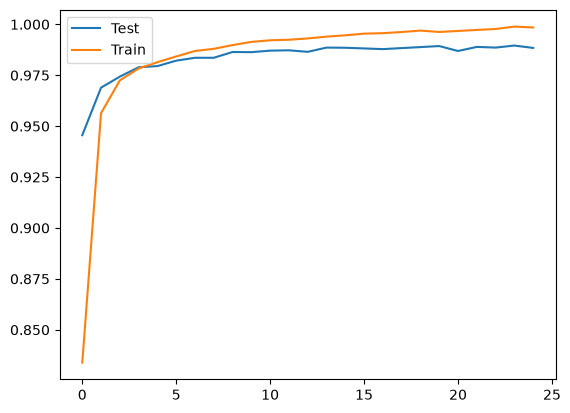

In [14]:
plt.plot(history.history['val_accuracy'], label='Test')
plt.plot(history.history['accuracy'], label='Train')

plt.legend()
plt.show()